In [3]:
#import libraries
import numpy as np 
import pandas as pd
import os

#config
base_path = "/kaggle/input/aptos2019-blindness-detection"
# base_path is currently set for Kaggle. To run locally set it to your dataset folder.

#Load data
df = pd.read_csv(f"{base_path}/train.csv")
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [4]:
#transform images, resize and normalize 

import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
#create dataset class and retun the image and label

from torch.utils.data import Dataset
from PIL import Image

class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]["id_code"]
        label = self.dataframe.iloc[idx]["diagnosis"]

        img_path = f"{self.img_dir}/{img_name}.png"
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [6]:
#create datasplit and dataloader

from torch.utils.data import DataLoader

img_dir = f"{base_path}/train_images"

dataset = APTOSDataset(df, img_dir, transform=transform)

from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [7]:
#see if data pipeline is correct 

images, labels = next(iter(train_loader))
print(images.shape)
print(labels)

torch.Size([16, 3, 224, 224])
tensor([0, 1, 0, 3, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])


In [8]:
# Models 
import torch.nn as nn
from torchvision.models import efficientnet_b0, mobilenet_v3_small
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#EfficientNet
efficient_model = efficientnet_b0(pretrained=True)
efficient_model.classifier[1] = nn.Linear(
    efficient_model.classifier[1].in_features, 5
)

#MobileNet
mobile_model = mobilenet_v3_small(pretrained=True)
mobile_model.classifier[3] = nn.Linear(
    mobile_model.classifier[3].in_features, 5
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 93.7MB/s]


In [9]:
#  train data

def train_model(model, train_loader, val_loader, epochs, device):

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        #train
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total


        #validation
        model.eval()
        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)
                running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total


        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [10]:
print("Training EfficientNet")

eff_train_loss, eff_val_loss, eff_train_acc, eff_val_acc = train_model(
    efficient_model, train_loader, val_loader, epochs=10, device=device
)

print("\nTraining MobileNet")

mob_train_loss, mob_val_loss, mob_train_acc, mob_val_acc = train_model(
    mobile_model, train_loader, val_loader, epochs=10, device=device
)

Training EfficientNet
Epoch 1/10 | Train Loss: 0.7090 | Train Acc: 0.7429 | Val Loss: 0.6586 | Val Acc: 0.7694
Epoch 2/10 | Train Loss: 0.5697 | Train Acc: 0.7815 | Val Loss: 0.5437 | Val Acc: 0.8254
Epoch 3/10 | Train Loss: 0.5332 | Train Acc: 0.8057 | Val Loss: 0.6395 | Val Acc: 0.7844
Epoch 4/10 | Train Loss: 0.4999 | Train Acc: 0.8191 | Val Loss: 0.5759 | Val Acc: 0.7981
Epoch 5/10 | Train Loss: 0.4383 | Train Acc: 0.8242 | Val Loss: 0.5306 | Val Acc: 0.8186
Epoch 6/10 | Train Loss: 0.4177 | Train Acc: 0.8375 | Val Loss: 0.4722 | Val Acc: 0.8404
Epoch 7/10 | Train Loss: 0.3923 | Train Acc: 0.8549 | Val Loss: 0.5321 | Val Acc: 0.7981
Epoch 8/10 | Train Loss: 0.3772 | Train Acc: 0.8573 | Val Loss: 0.5245 | Val Acc: 0.8158
Epoch 9/10 | Train Loss: 0.3974 | Train Acc: 0.8597 | Val Loss: 0.5012 | Val Acc: 0.8254
Epoch 10/10 | Train Loss: 0.3842 | Train Acc: 0.8672 | Val Loss: 0.5247 | Val Acc: 0.8158

Training MobileNet
Epoch 1/10 | Train Loss: 0.7175 | Train Acc: 0.7340 | Val Loss: 0.5

In [4]:
#EfficientNet results
eff_train_losses = [0.7090,0.5697,0.5332,0.4999,0.4383,0.4177,0.3923,0.3772,0.3974,0.3842]
eff_val_losses   = [0.6586,0.5437,0.6395,0.5759,0.5306,0.4722,0.5321,0.5245,0.5012,0.5247]

eff_train_accs = [0.7429,0.7815,0.8057,0.8191,0.8242,0.8375,0.8549,0.8573,0.8597,0.8672]
eff_val_accs   = [0.7694,0.8254,0.7844,0.7981,0.8186,0.8404,0.7981,0.8158,0.8254,0.8158]


#MobileNet results
mob_train_losses = [0.7175,0.5629,0.5007,0.4823,0.4759,0.4811,0.4351,0.4072,0.4166,0.4082]
mob_val_losses   = [0.5968,0.6556,0.6272,1.0218,0.6707,0.5977,0.8730,0.7320,0.5746,0.9916]

mob_train_accs = [0.7340,0.7907,0.8102,0.8231,0.8262,0.8330,0.8532,0.8426,0.8628,0.8518]
mob_val_accs   = [0.7817,0.7926,0.7558,0.6030,0.7613,0.7735,0.6344,0.7544,0.8090,0.7585]

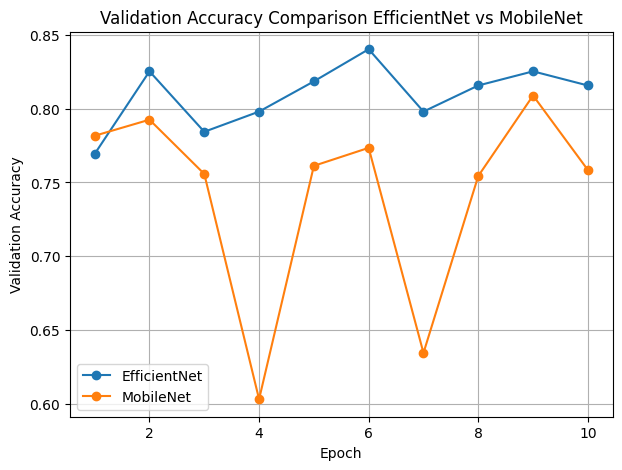

In [5]:
import matplotlib.pyplot as plt

epochs = range(1,11)

plt.figure(figsize=(7,5))
plt.plot(epochs, eff_val_accs, marker='o', label="EfficientNet")
plt.plot(epochs, mob_val_accs, marker='o', label="MobileNet")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison EfficientNet vs MobileNet")
plt.legend()
plt.grid(True)
plt.show()

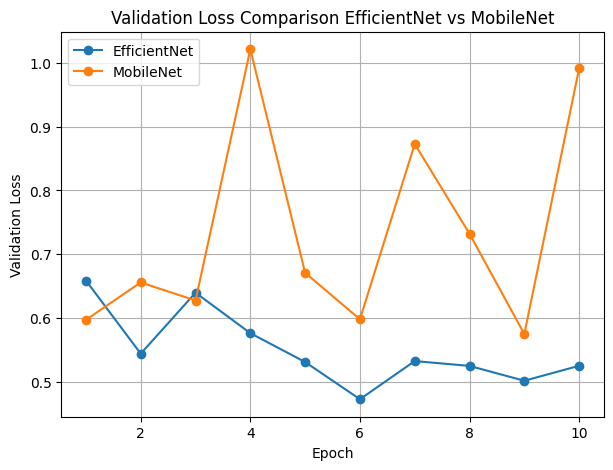

In [6]:
plt.figure(figsize=(7,5))
plt.plot(epochs, eff_val_losses, marker='o', label="EfficientNet")
plt.plot(epochs, mob_val_losses, marker='o', label="MobileNet")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison EfficientNet vs MobileNet")
plt.legend()
plt.grid(True)
plt.show()